In [ ]:
import os
# mac-specific dylib fixes, otherwise cairosvg / torch stuff can randomly break
os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = "/opt/homebrew/lib"
os.environ["DYLD_LIBRARY_PATH"] = "/opt/homebrew/lib"
os.environ["PKG_CONFIG_PATH"] = "/opt/homebrew/lib/pkgconfig"

from gpt_library import save_plot  # quick plotting helper
import global_config as cfg
import torch
from tokenizers import Tokenizer
import model_design as gpt
import numpy as np
import cairosvg
from PIL import Image
import io
import matplotlib.pyplot as plt
import re
import xml.etree.ElementTree as etree

device = cfg.DEVICE
ckpt_path = 'model_data/bestmod'

# tokenizer trained separately on svg corpus
tokenizer = Tokenizer.from_file("data/tokenizer.json")

encode = lambda s: tokenizer.encode(s).ids
decode = lambda l: tokenizer.decode(l)

# test set is stored as raw token stream
test_data = np.memmap('data/rob_test_set.bin', dtype=np.uint16, mode='r')

# rebuild model from checkpoint config
checkpoint = torch.load(ckpt_path, map_location=device)
config = gpt.GPTConfig(**checkpoint['config'])
model = gpt.GPT(config)

# mup needs base shape alignment step
if config.use_mup:
    import mup
    base_config = gpt.GPTConfig(**checkpoint['config'])

    # override width for base model (mup requirement)
    base_config.n_embd = config.base_width
    base_model = gpt.GPT(base_config)

    # align parameterization between base and target model
    mup.set_base_shapes(model, base_model)
    del base_model

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

In [ ]:
# =========================
# post-processing helpers
# =========================

import re

def fix_decimal_spacing(text: str):
    """cleans up tokenization artifacts around numbers"""
    # fixes spaced decimals like "1 . 2" -> "1.2"
    text = re.sub(r"(\d)\s*\.\s*(\d)", r"\1.\2", text)

    # fixes negative spacing like "- 1" -> "-1"
    text = re.sub(r"-\s+(\d)", r"-\1", text)
    return text


def extract_first_svg(text: str):
    """
    tries to recover first valid svg block
    handles both clean completion and truncated outputs
    """

    # end anchor if model actually closed svg
    end_idx = text.lower().find("</svg>")

    # all possible svg starts
    starts = list(re.finditer(r"<svg\b[^>]*>", text, flags=re.I))

    if not starts:
        return None

    # case: clean completion with closing tag
    if end_idx != -1:
        # only consider svg starts before closing tag (avoids junk prefixes)
        valid_starts = [m for m in starts if m.start() < end_idx]
        if not valid_starts:
            return None

        start_idx = valid_starts[-1].start()
        return text[start_idx:end_idx + 6]

    # case: truncated output (no closing tag)
    start_idx = starts[-1].start()
    truncated_text = text[start_idx:]

    # try to gracefully complete closing pattern
    target_close = '"/></svg>'

    overlap_len = 0
    for i in range(len(target_close), 0, -1):
        if truncated_text.endswith(target_close[:i]):
            overlap_len = i
            break

    return truncated_text + target_close[overlap_len:]

In [ ]:
def is_xml_valid(text: str) -> bool:
    """strict xml parse check (catches malformed svg)"""
    if not text:
        return False
    try:
        etree.fromstring(text.encode('utf-8'))
        return True
    except Exception:
        return False


def is_render_valid(text: str) -> bool:
    """actual render check via cairosvg (more expensive but real signal)"""
    if not text:
        return False
    try:
        cairosvg.svg2png(bytestring=text.encode("utf-8"))
        return True
    except Exception:
        return False


def is_structurally_valid(text: str):
    """
    lightweight structural sanity check

    checks:
    - has svg tag
    - has closing svg tag
    - has at least one path (starvector style emphasis)
    """
    if not text:
        return False, False, False, False

    has_open = bool(re.search(r'<svg\b[^>]*>', text, re.IGNORECASE))
    has_close = bool(re.search(r'</svg>', text, re.IGNORECASE))

    # starvector bias: paths carry most geometry
    has_shape = bool(re.search(r'<path\b', text, re.IGNORECASE))

    all_structure = has_open and has_close and has_shape

    return has_open, has_close, has_shape, all_structure


In [ ]:
def evaluate_samples(generated_samples):
    """aggregates raw + processed svg quality metrics"""

    metrics = {
        'total': len(generated_samples),
        'raw': {
            'xml': 0, 'render': 0, 'open': 0, 'close': 0, 'shape': 0, 'all_structure': 0
        },
        'processed': {
            'xml': 0, 'render': 0, 'open': 0, 'close': 0, 'shape': 0, 'all_structure': 0
        }
    }

    if metrics['total'] == 0:
        return metrics

    for sample in generated_samples:
        raw = sample.get('raw_text', '')
        processed = sample.get('full_svg', '')

        # raw metrics (before cleanup/extraction)
        if is_xml_valid(raw): metrics['raw']['xml'] += 1
        if is_render_valid(raw): metrics['raw']['render'] += 1

        r_open, r_close, r_shape, r_all = is_structurally_valid(raw)
        if r_open: metrics['raw']['open'] += 1
        if r_close: metrics['raw']['close'] += 1
        if r_shape: metrics['raw']['shape'] += 1
        if r_all: metrics['raw']['all_structure'] += 1

        # processed metrics (after cleanup/extraction)
        safe_processed = processed if processed else ""

        if is_xml_valid(safe_processed): metrics['processed']['xml'] += 1
        if is_render_valid(safe_processed): metrics['processed']['render'] += 1

        p_open, p_close, p_shape, p_all = is_structurally_valid(safe_processed)
        if p_open: metrics['processed']['open'] += 1
        if p_close: metrics['processed']['close'] += 1
        if p_shape: metrics['processed']['shape'] += 1
        if p_all: metrics['processed']['all_structure'] += 1

    return metrics


In [ ]:
def print_metric_results(metrics):
    """pretty prints eval stats with percentages"""

    total = metrics['total']

    if total == 0:
        print("no samples")
        return

    def fmt(count):
        pct = (count / total) * 100
        return f"{count}/{total} ({pct:05.2f}%)"

    print("\n" + "="*50)
    print(f"metrics | total: {total}")
    print("="*50)

    for version in ['raw', 'processed']:
        print(f"\n{version}")

        m = metrics[version]
        print(f"xml       : {fmt(m['xml'])}")
        print(f"render    : {fmt(m['render'])}")

        # structure breakdown (useful for debugging generation collapse)
        print(f"open svg  : {fmt(m['open'])}")
        print(f"close svg : {fmt(m['close'])}")
        print(f"path tags : {fmt(m['shape'])}")
        print(f"all good  : {fmt(m['all_structure'])}")


In [6]:
def show_svg_clean(svg_str, title, save_path=None):
    """renders svg -> png via cairosvg and displays via matplotlib"""

    try:
        png_bytes = cairosvg.svg2png(bytestring=svg_str.encode("utf-8"))
        img = Image.open(io.BytesIO(png_bytes)).convert("RGBA")

        # force white background (svg transparency issues otherwise)
        white_bg = Image.new("RGBA", img.size, "WHITE")
        white_bg.paste(img, (0, 0), img)
        img_rgb = white_bg.convert("RGB")

        plt.figure(figsize=(4, 4), facecolor='white')
        plt.title(title)
        plt.imshow(img_rgb)
        plt.axis("off")

        # optional save hook
        if save_path:
            save_plot(title)

        plt.show()
        plt.close()
        return True

    except Exception as e:
        print(f"render failed: {e}")
        return False



In [ ]:
def generate_from_strings(model, tokenizer, prompts, temp=0.8, top_k=40, max_context=512, target_im=None):
    """
    basic batch generator wrapper

    note:
    - truncates prompts if needed
    - extracts first valid svg per sample
    """

    results = []

    for i, prompt_text in enumerate(prompts):

        # encode prompt into token ids
        prompt_ids = tokenizer.encode(prompt_text).ids
        x = torch.tensor(prompt_ids, dtype=torch.long, device=device)[None, :]

        # ensure we don't exceed context window
        safe_max_gen = max_context - len(prompt_ids)
        if safe_max_gen <= 0:
            print(f"prompt too long")
            continue

        with torch.no_grad():
            y = model.generate(x, max_new_tokens=safe_max_gen, temperature=temp, top_k=top_k)

        raw_text = decode(y[0].tolist())

        # light cleanup before svg extraction
        processed_text = fix_decimal_spacing(raw_text)
        final_svg = extract_first_svg(processed_text)

        results.append({
            "id": i + 1,
            "prompt_text": prompt_text,
            "full_svg": final_svg,
            "temp": temp,
            "raw_text": raw_text,
            "target": target_im[i] if target_im is not None else None
        })

    return results


In [ ]:
def test_set_generation(model, test_data, num_samples=5, prompt_len=70, max_gen=300, temp=0.1):
    """
    builds prompts from real dataset slices

    idea:
    - find svg start tokens
    - sample from those regions
    - let model continue completion
    """

    # token-based svg detection (<svg starts are encoded patterns)
    indices = np.where(test_data == 19)[0]
    valid_starts = [i for i in indices if i + 1 < len(test_data) and test_data[i+1] == 89]

    if not valid_starts:
        print("no svg patterns found")
        return []

    selected_starts = np.random.choice(
        valid_starts,
        size=min(num_samples, len(valid_starts)),
        replace=False
    )

    results = []

    for i, start_idx in enumerate(selected_starts):

        prompt_ids = test_data[start_idx : start_idx + prompt_len].tolist()
        x = torch.tensor(prompt_ids, dtype=torch.long, device=device)[None, :]

        with torch.no_grad():
            y = model.generate(x, max_new_tokens=max_gen, temperature=temp, top_k=40)

        raw_text = decode(y[0].tolist())
        processed_text = fix_decimal_spacing(raw_text)
        final_svg = extract_first_svg(processed_text)

        results.append({
            "id": i + 1,
            "prompt_text": decode(prompt_ids),
            "full_svg": final_svg,
            "raw_text": raw_text
        })

    return results

PROMPT PREFIX:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M10.7 20.1 L11.3 19.8 C12.1 18.7 12.9 17.5 13.4 16.3
PROMPT PREFIX:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M10.7 20.1 L11.3 19.8 C12.1 18.7 12.9 17.5 13.4 16.3

GENERATED SVG:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M10.7 20.1 L11.3 19.8 C12.1 18.7 12.9 17.5 13.4 16.3 C13.9 15.1 14.2 13.8 14.1 12.4 C14.1 11.8 13.6 11.2 13.9 10.8 C14.2 10.4 14.7 10.2 15.1 9.9 L15.1 9.9 C15.3 10.2 15.5 10.5 15.6 10.8 L15.6 11.2 C15.6 11.3 15.6 11.4 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 15.6 11.5 L15.6 11.5 C15.6 11.5 15.6 11.5 

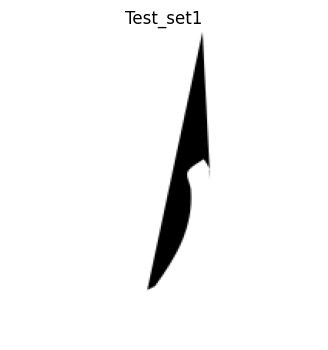

PROMPT PREFIX:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M17.9 17 L17.9 17 C17.7 18.7 17.1 20.4 16.2 21.9 C15.3
PROMPT PREFIX:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M17.9 17 L17.9 17 C17.7 18.7 17.1 20.4 16.2 21.9 C15.3

GENERATED SVG:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M17.9 17 L17.9 17 C17.7 18.7 17.1 20.4 16.2 21.9 C15.3 23.3 14.1 24.6 12.6 25.5 C11.3 26.3 9.8 26.8 8.2 26.8 C7.8 26.8 7.3 26.8 7.1 26.4 C6.9 26.1 7.6 26.1 7.8 26 C9.2 25.5 10.6 24.8 11.8 24 L11.8 24 C12.9 22.7 13.8 21.3 14.5 19.8 C15.2 18.3 15.6 16.7 16 14.9 C16.2 14.1 16.4 13.3 16.5 12.5 C16.6 12.1 16.7 11.7 16.8 11.3 C17.2 10.2 18.1 7.7 16.2 7.6 C14.7 7.5 14.1 9.5 13.6 10.5 C13.3 11.2 13.1 11.9 12.8 12.5 C12.5 13.1 12.1 13.6 11.8 14.2 C11.6 14.6 11.5 15.1 11.3 15.5 C10.9 16.3 10.4 17.1 10.1 18 C9.9 18.5 9.3 19.7 9.5 20.2 C9.8 20.8 10.5 21.2 

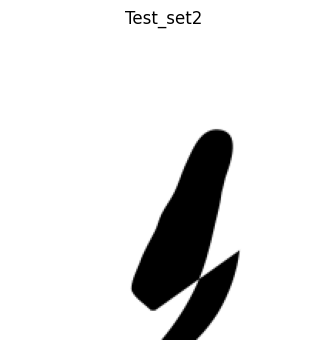

PROMPT PREFIX:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M7.9 13.5 L8.2 13.3 C9.7 12.8 10.5 12.7 10.7 14.6
PROMPT PREFIX:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M7.9 13.5 L8.2 13.3 C9.7 12.8 10.5 12.7 10.7 14.6

GENERATED SVG:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M7.9 13.5 L8.2 13.3 C9.7 12.8 10.5 12.7 10.7 14.6 L10.7 14.6 C11.2 13.8 11.6 13.1 12.5 12.7 C14.3 11.9 15.6 12.6 16.4 13.8 C17.2 15 17.5 16.8 17.1 18.3 C16.7 19.9 15.7 21.2 14.3 21.9 C12.9 22.7 11.2 23 9.6 22.8 C8 22.5 6.6 21.6 6.1 19.9 C5.7 18.4 6.1 16.9 6.6 15.5 C7.1 14.1 7.9 12.8 7.9 13.5 L7.9 13.5" fill="none" filling="0" stroke="black" stroke-opacity="1.0" stroke-width=".3"/><path d="M9.5 21.5 L9.5 21.5 C8.8 21.3 8.1 21.1 7.6 20.6 C6.3 19.4 6.3 17.7 6.9 16.2 C7.5 14.7 8.8 13.3 10.2 12.9 C11.6 12.4 13.2 12.7 14.3 14.2 C15.2 15.4 15.4 16.9 15.1 18.3 C

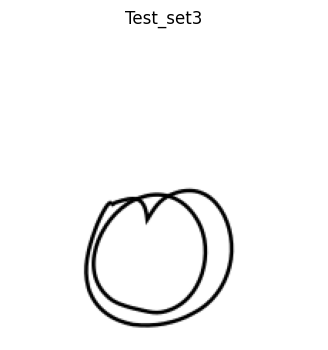

In [9]:

#generate from test sets examples

num_to_generate = 2
prompt_len = 70
max = 512-prompt_len #never gen more than context window

generated_samples = test_set_generation(
    model=model,
    test_data=test_data,
    num_samples=3,
    prompt_len=prompt_len,
    max_gen=max,
    temp=0.1
)


for res in generated_samples:
    print(f"PROMPT PREFIX:\n{res['prompt_text']}")
    print(f"PROMPT PREFIX:\n{res['prompt_text']}")
    print(f"\nGENERATED SVG:\n{res['raw_text']}")

    if res['full_svg']:
        # attempt render and capture the result
        is_success = show_svg_clean(res['full_svg'], title=f"Test_set{res['id']}", save_path='x')







RUNNING UNCONDITIONAL SAMPLES (Varying Temps)

--- Generating Unconditional at Temperature: 0.2 ---

--- Generating Unconditional at Temperature: 0.4 ---

--- Generating Unconditional at Temperature: 0.6 ---

--- Generating Unconditional at Temperature: 0.8 ---

--- Generating Unconditional at Temperature: 1.0 ---


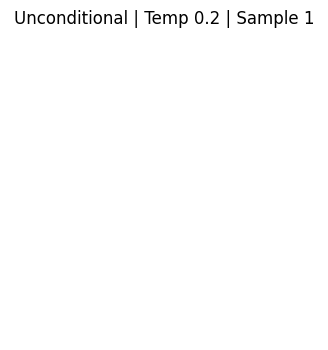

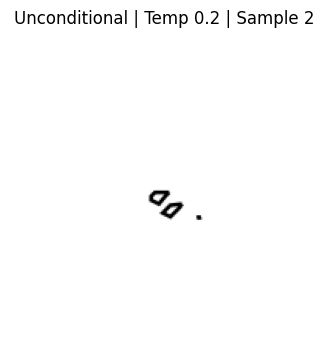

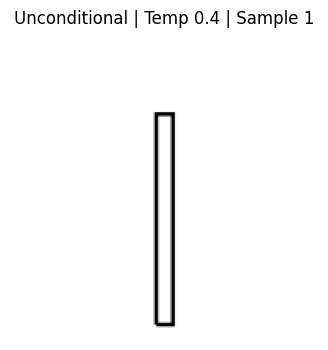

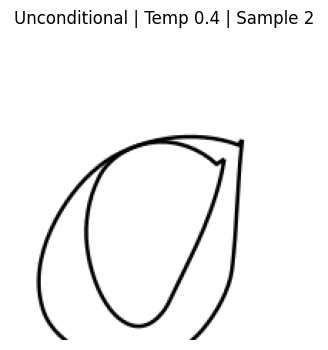

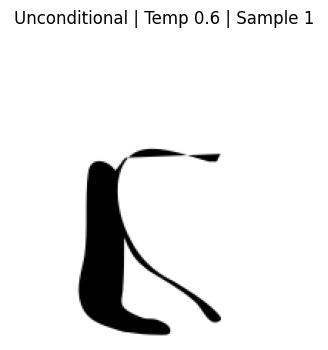

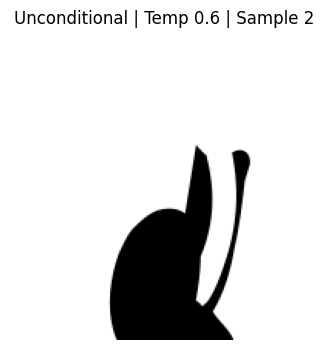

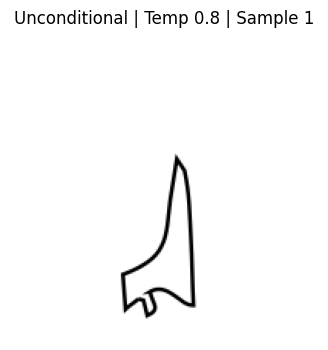

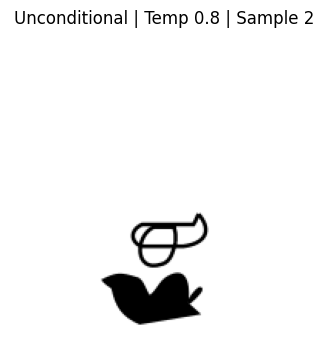

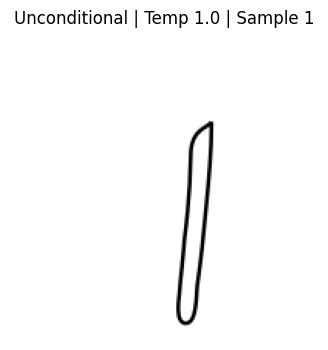

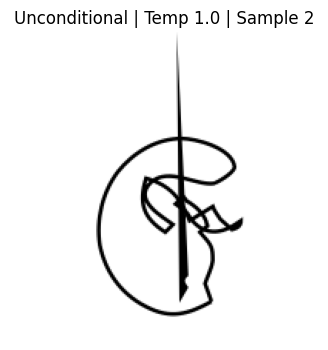


Unconditional Render Success Rate: 10/10


In [10]:
# ==========================================
# UNCONDITIONAL GENERATION
# ==========================================
print("\n" + "="*50)
print("RUNNING UNCONDITIONAL SAMPLES (Varying Temps)")
print("="*50)

unconditional_prefix = '<svg'

#sweep temps
test_temperatures = [0.2, 0.4, .6, .8, 1.0]
uncond_results = []

for temp in test_temperatures:
    print(f"\n--- Generating Unconditional at Temperature: {temp} ---")
    # get two per temp
    prompts = [unconditional_prefix] * 2
    batch_results = generate_from_strings(model, tokenizer, prompts, temp=temp, top_k=40)
    uncond_results.extend(batch_results)

# render and track Unconditional
uncond_success = 0
for res in uncond_results:
    if res['full_svg']:
        is_success = show_svg_clean(res['full_svg'], title=f"Unconditional | Temp {res['temp']} | Sample {res['id']}", save_path=f'unconditional_t{res['temp']}_id{res['id']}')
        if is_success: uncond_success += 1

print(f"\nUnconditional Render Success Rate: {uncond_success}/{len(uncond_results)}")



In [11]:

conditional_prompts = [
    # rocket ship
    '<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><rect x="9" y="8" width="6" height="10" fill="none" stroke="black" /><path d="M9 8 Q12 2 15 8 ',

    # partial curve
    '<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M10 10 C 12 8 14 8 ',

    # draws three sides of square
    '<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M5 5 L 19 5 L 19 19 L 5 19 ',

    # close one path, starts another
    '<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M12 2 L 12 22" fill="none" stroke="black" stroke-width="1"/><path d="',

    # partial smiley face
    '<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><circle cx="12" cy="12" r="10" fill="none" stroke="black" /><path d="M8 9 A1 1 0 1 1 8 8 M16 9 A1 1 0 1 1 16 8 M7 14 Q12 18 17 14',

    # the letter A
    '<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path fill="none" stroke="black" stroke-width="2" d="M4 20 L 12 4 ',
]
target_shape = ['Rocket Ship', 'Curve', 'Square', 'Random Multipath', 'Smiley Face', 'Letter A']



cond_results = generate_from_strings(model, tokenizer, conditional_prompts, temp=0.4, top_k=40, target_im=target_shape)


Condition Prompt 1:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><rect x="9" y="8" width="6" height="10" fill="none" stroke="black" /><path d="M9 8 Q12 2 15 8 


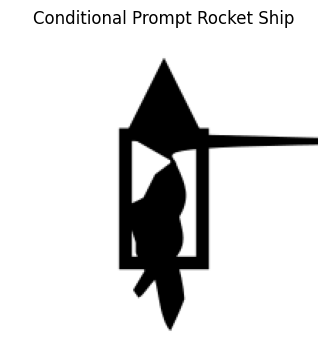


Condition Prompt 2:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M10 10 C 12 8 14 8 


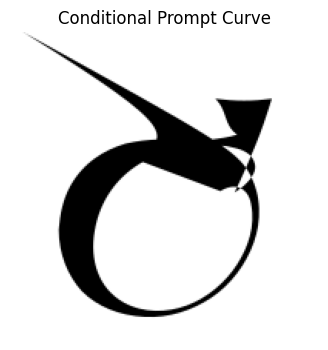


Condition Prompt 3:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M5 5 L 19 5 L 19 19 L 5 19 


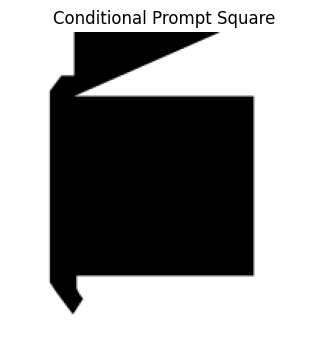


Condition Prompt 4:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path d="M12 2 L 12 22" fill="none" stroke="black" stroke-width="1"/><path d="


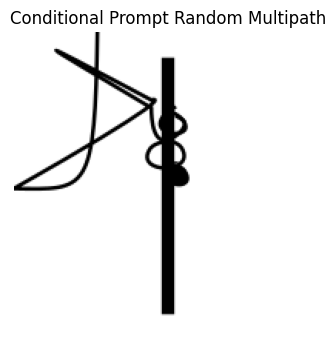


Condition Prompt 5:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><circle cx="12" cy="12" r="10" fill="none" stroke="black" /><path d="M8 9 A1 1 0 1 1 8 8 M16 9 A1 1 0 1 1 16 8 M7 14 Q12 18 17 14


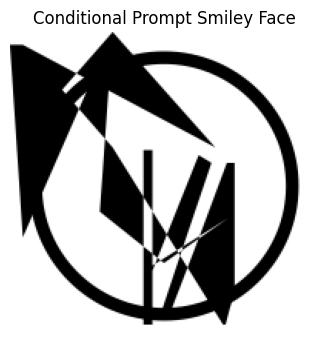


Condition Prompt 6:
<svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><path fill="none" stroke="black" stroke-width="2" d="M4 20 L 12 4 
[!] Render Failed: duplicate attribute: line 1, column 665

Conditional Render Success Rate: 5/6


In [12]:

# render/track
cond_success = 0
for res in cond_results:
    print(f"\nCondition Prompt {res['id']}:\n{res['prompt_text']}")
    if res['full_svg']:
        is_success = show_svg_clean(res['full_svg'], title=f"Conditional Prompt {res['target']}", save_path=f"conditional_id{res['id']}")
        if is_success: cond_success += 1

print(f"\nConditional Render Success Rate: {cond_success}/{len(cond_results)}")


In [13]:
# print conditioned output
for i in range(len(conditional_prompts)):
    print(f"prompt: {conditional_prompts[i]}\n")
    print(f"target: {target_shape[i]}\n")
    print(f"raw model output: {cond_results[i]['raw_text']}\n")
    print(f"post-processed model output: {cond_results[i]['full_svg']}\n")
    print("-" * 40)


prompt: <svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><rect x="9" y="8" width="6" height="10" fill="none" stroke="black" /><path d="M9 8 Q12 2 15 8 

target: Rocket Ship

raw model output: <svg xmlns="http://www.w3.org/2000/svg" height="200px" viewBox="0 0 24 24" width="200px"><rect x="9" y="8" width="6" height="10" fill="none" stroke="black" /><path d="M9 8 12 2 15 8  L37 8.6 C11.5 8.9 12.1 9.1 12.9 10.1 L13 10.4 C13.7 11.9 14.1 12.9 13.2 14.4 L13.2 14.4 C13.5 15.7 13.8 16.5 12.9 17.6 L12.9 17.6 C13.3 18.6 13.5 19.7 13.6 20.8 L13.6 20.8 C13.3 21.6 12.9 22.5 12.5 23.3 L12.5 23.3 C11.7 22.4 11.6 20.4 11.3 19.3 L11.3 19.3 C10.9 19.7 10.6 20.2 10.2 20.6 L10.2 20.6 C10.1 20.6 10.1 20.7 10 20.7 L10 20.7 C9.9 20.5 9.7 20.3 9.6 20.1 L9.6 20.1 C9.9 19.6 10.2 19.1 10.5 18.6 L10.5 18.6 C10.2 18.1 10 17.7 9.8 17.2 L9.8 17.2 C9.8 16.9 9.8 16.7 9.8 16.4 L9.8 16.4 C9.6 15.8 9.4 15.2 9.2 14.6 L9.2 14.6 C9.1 14.3 8.9 14 8.8 13.7 L8.8 13.7 C9.3 13.4 9.9 13.2 1

In [15]:
#print sampling successes and metcis
all_model_outputs = []

if 'cond_results' in locals():
    all_model_outputs.extend(cond_results)
if 'uncond_results' in locals():
    all_model_outputs.extend(uncond_results)



print("\n" + "*" * 50)
print("UNCONDITIONAL STATS...")
print("*" * 50)
uncond_metrics = evaluate_samples(uncond_results)
print_metric_results(uncond_metrics)
print("\n" + "*" * 50)
print("CONDITIONAL STATS...")
print("*" * 50)
cond_metrics = evaluate_samples(cond_results)
print_metric_results(cond_metrics)
print("\n" + "*" * 50)
print("ALL DRAWS...")
print("*" * 50)
final_report_metrics = evaluate_samples(all_model_outputs)
print_metric_results(final_report_metrics)




**************************************************
RUNNING FINAL METRICS PIPELINE...
**************************************************

**************************************************
UNCONDITIONAL STATS...
**************************************************

QUANTITATIVE METRICS REPORT | Total Samples: 10

--- RAW TEXT METRICS ---
  XML Validity Rate       : 0/10 (00.00%)
  SVG Render Rate         : 0/10 (00.00%)
  - - - - - - - - - - - - -
  Structure: Has <svg>    : 10/10 (100.00%)
  Structure: Has </svg>   : 4/10 (40.00%)
  Structure: Has <path>   : 10/10 (100.00%)
  Structure: ALL VALID    : 4/10 (40.00%)

--- PROCESSED TEXT METRICS ---
  XML Validity Rate       : 10/10 (100.00%)
  SVG Render Rate         : 10/10 (100.00%)
  - - - - - - - - - - - - -
  Structure: Has <svg>    : 10/10 (100.00%)
  Structure: Has </svg>   : 10/10 (100.00%)
  Structure: Has <path>   : 10/10 (100.00%)
  Structure: ALL VALID    : 10/10 (100.00%)

**************************************************
UN

In [ ]:

def evaluate_test_set(model, test_data, context_length=512, batch_size=16, eval_iters=50, device='mps'):
    """
    standard language modeling eval

    returns:
    - avg loss
    - perplexity
    - loss trace
    """

    model.eval()
    losses = torch.zeros(eval_iters)
    max_idx = len(test_data) - context_length - 1

    with torch.no_grad():
        for k in range(eval_iters):
            # random windows from dataset
            ix = torch.randint(0, max_idx, (batch_size,))

            x = torch.stack([
                torch.from_numpy(test_data[i: i + context_length].astype(np.int64))
                for i in ix
            ])
            y = torch.stack([
                torch.from_numpy(test_data[i + 1: i + 1 + context_length].astype(np.int64))
                for i in ix
            ])

            x, y = x.to(device), y.to(device)

            logits, loss = model(x, targets=y)
            losses[k] = loss.item()

    avg_loss = losses.mean().item()
    perplexity = math.exp(avg_loss)

    return avg_loss, perplexity, losses


# final test run + plot
test_loss, test_perplexity, loss_curve = evaluate_test_set(
    model=model,
    test_data=test_data,
    context_length=512,
    batch_size=16,
    eval_iters=100,
    device=device
)

print("\n" + "="*40)
print("FINAL TEST SET METRICS")
print("="*40)
print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Perplexity : {test_perplexity:.4f}")

In [ ]:
#quick plot test set loss
plt.figure(figsize=(8, 5))

plt.plot(loss_curve, color='#2c3e50', linewidth=1.5, label='Test Loss')


plt.title(f"Test Set Evaluation\nLoss: {test_loss:.4f} | Perplexity: {test_perplexity:.4f}", fontsize=12)
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.grid(True, which='both', linestyle='--', alpha=0.5)
#avg line
plt.axhline(y=test_loss, color='red', linestyle=':', alpha=0.8, label=f'Avg: {test_loss:.4f}')

plt.legend()

save_plot("test_loss.png", "visualizations")

plt.show()